In [1]:
%matplotlib inline
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
if not (repo_root / "backtesting" / "renquant_101").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import common

# Keep the strategy gate local to the notebook so analysis uses the exact same
# signal definition as model generation.
def add_gate_signals(df):
    df = df.copy()
    df["buy_signal"] = (
        (df["macd_line"] > df["macd_signal"])
        & (df["macd_line"].shift(1) <= df["macd_signal"].shift(1))
        & (df["rsi"] > 50)
    )
    df["sell_signal"] = (
        (df["macd_line"] < df["macd_signal"])
        & (df["macd_line"].shift(1) >= df["macd_signal"].shift(1))
        & (df["rsi"] < 50)
    )
    return df

STRATEGY_DIR = repo_root / "backtesting" / "renquant_101"
config = common.load_strategy_config(STRATEGY_DIR / "strategy_config.json")

result, result_path = common.load_latest_backtest(STRATEGY_DIR)
state = result.get("state", {})
print(f"Run:     {result_path.parent.name}")
print(f"Status:  {state.get('Status')}")
print(f"Orders:  {state.get('OrderCount', 0)}")

Run:     2026-03-26_16-48-14
Status:  Completed
Orders:  9


In [2]:
# Rebuild the indicator frame over the exact backtest window so the dashboard can
# overlay the same buy/sell gates used during training.
algo_cfg = result.get("algorithmConfiguration", {})
period_start = algo_cfg.get("startDate", config.get("backtest_start", ""))[:10]
period_end = algo_cfg.get("endDate", config.get("backtest_end", ""))[:10]

df = common.fetch_ohlcv(
    config["stock_symbol"],
    start=period_start,
    end=period_end,
    provider=config["data_src"],
)
df = common.add_indicators(df).pipe(add_gate_signals).dropna()

print(f"Price data:  {df.index[0]} -> {df.index[-1]}  ({len(df)} bars)")
print(f"Buy signals: {df['buy_signal'].sum()}")
print(f"Sell signals: {df['sell_signal'].sum()}")

Price data:  2024-01-30 00:00:00 -> 2026-03-25 00:00:00  (540 bars)
Buy signals: 17
Sell signals: 13


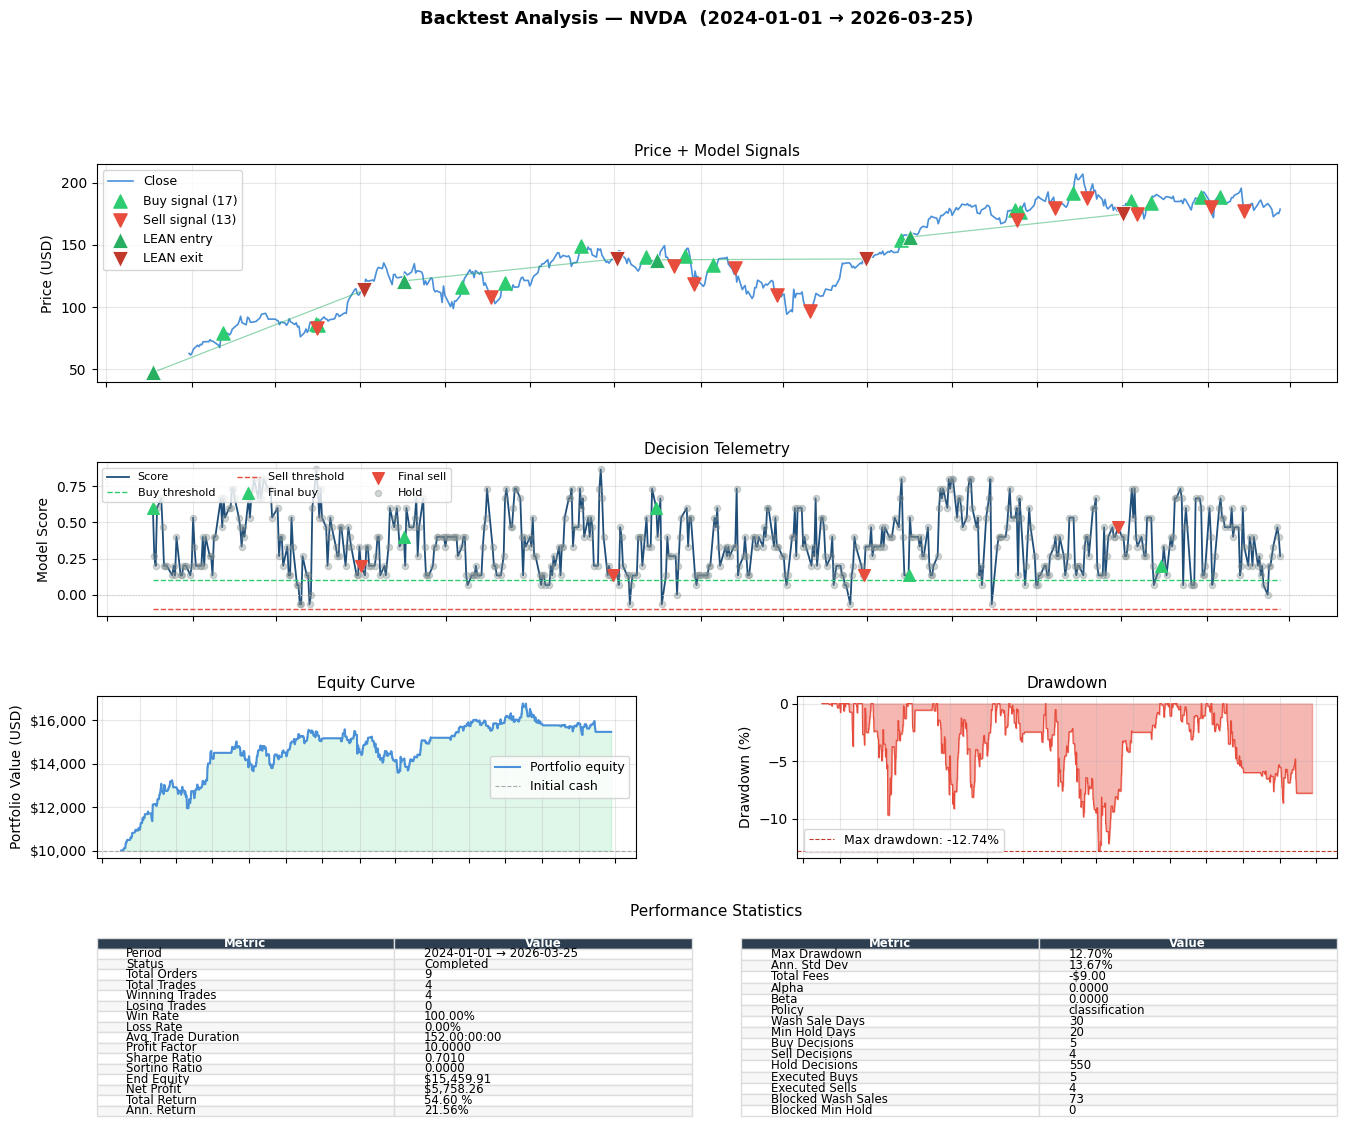

In [3]:
fig = common.backtest_dashboard(
    price_df=df,
    result=result,
    symbol=config["stock_symbol"],
    initial_cash=config.get("initial_cash", 100_000),
)
fig.savefig(STRATEGY_DIR / "backtests" / result_path.parent.name / "dashboard.png",
            dpi=150, bbox_inches="tight")

In [ ]:
# ── After-Tax Trade Analysis ──────────────────────────────────────────────
tax_config = common.load_tax_config(config)
trades = common.parse_closed_trades(result)

if not trades.empty:
    trades_tax = common.add_tax_columns(trades, tax_config)

    # Per-trade table
    display_cols = ["symbol", "direction", "quantity", "entry_time", "exit_time",
                    "entry_price", "exit_price", "holding_days", "pnl", "tax_rate", "tax", "after_tax_pnl"]
    display_df = trades_tax[display_cols].copy()
    display_df["entry_time"] = display_df["entry_time"].dt.strftime("%Y-%m-%d")
    display_df["exit_time"] = display_df["exit_time"].dt.strftime("%Y-%m-%d")
    for col in ["entry_price", "exit_price", "pnl", "tax", "after_tax_pnl"]:
        display_df[col] = display_df[col].map("${:,.2f}".format)
    display_df["tax_rate"] = trades_tax["tax_rate"].map("{:.0%}".format)
    print("Closed Trades (After-Tax):")
    display(display_df)

    # Aggregate summary
    total_gross = trades_tax["pnl"].sum()
    total_tax = trades_tax["tax"].sum()
    total_after_tax = trades_tax["after_tax_pnl"].sum()
    n_st = (trades_tax["holding_days"] < tax_config["long_term_threshold_days"]).sum()
    n_lt = len(trades_tax) - n_st
    eff_rate = total_tax / total_gross if total_gross > 0 else 0

    print(f"\n{'='*50}")
    print(f"Tax Summary")
    print(f"{'='*50}")
    print(f"Short-term rate:    {tax_config['short_term_rate']:.0%} (<{tax_config['long_term_threshold_days']}d)")
    print(f"Long-term rate:     {tax_config['long_term_rate']:.0%} (>={tax_config['long_term_threshold_days']}d)")
    print(f"Short-term trades:  {n_st}")
    print(f"Long-term trades:   {n_lt}")
    print(f"Gross P&L:          ${total_gross:,.2f}")
    print(f"Tax Paid:           ${total_tax:,.2f}")
    print(f"After-Tax P&L:      ${total_after_tax:,.2f}")
    print(f"Effective Tax Rate: {eff_rate:.0%}")
    print(f"{'='*50}")
else:
    print("No closed trades found in backtest results.")